# Προσομοίωση Εναλλαγής Κυττάρων σε Δίκτυο 4G

## Εισαγωγή Βιβλιοθηκών

In [3]:
# Εισάγουμε τη βιβλιοθήκη για τη τυχαιότητα.
import random
# Εισάγουμε τη βιβλιοθήκη για τις μαθηματικές συναρτήσεις.
import math
# Εισάγουμε τη βιβλιοθήκη NumPy για αριθμητικές πράξεις και διαχείριση πινάκων.
import numpy as np
# Εισάγουμε τη βιβλιοθήκη Matplotlib για τη δημιουργία γραφημάτων.
import matplotlib.pyplot as plt
# Εισάγουμε τη βιβλιοθήκη για συνδυασμούς και διατάξεις στοιχείων.
import itertools

## Κλάση Σταθμού Βάσης

In [4]:
class BaseStation:
    def __init__(self, id, x, y, coverage_radius=65):
        """
        Αρχικοποιεί έναν σταθμό βάσης με μοναδικό ID, θέση, ακτίνα κάλυψης και αρχικό φορτίο.
        Args:
            id (int): Το ID του σταθμού βάσης.
            x (float): Η συντεταγμένη X του σταθμού βάσης.
            y (float): Η συντεταγμένη Y του σταθμού βάσης.
            coverage_radius (float): Η ακτίνα κάλυψης του σταθμού βάσης.
        """
        self.id = id  # Αποθήκευση του μοναδικού ID του σταθμού βάσης
        self.x = x  # Αποθήκευση της συντεταγμένης X του σταθμού βάσης
        self.y = y  # Αποθήκευση της συντεταγμένης Y του σταθμού βάσης
        self.coverage_radius = coverage_radius  # Ορισμός της ακτίνας κάλυψης του σταθμού βάσης
        self.load = random.uniform(0.1, 1.0)  # Τυχαία αρχικοποίηση του φορτίου του σταθμού βάσης
        self.connected_ues = 0  # Αριθμός συνδεδεμένων UEs (συσκευών χρηστών)

    def update_load(self):
        """
        Ενημερώνει το φορτίο του σταθμού βάσης με βάση τον αριθμό των συνδεδεμένων συσκευών UE.
        """
        self.load = self.connected_ues / 10 + random.uniform(0.5, 1.5)  # Υπολογισμός του νέου φορτίου με βάση τον αριθμό των συνδεδεμένων UEs και μια τυχαία διακύμανση
        self.load = max(0.1, min(1.0, self.load))  # Περιορισμός του φορτίου μεταξύ 0.1 και 1.0

    def get_signal_strength(self, ue):
        """
        Υπολογίζει την ισχύ σήματος (SNR) για μια συγκεκριμένη συσκευή UE.
        Args:
            ue (UE): Η συσκευή UE για την οποία υπολογίζεται η ισχύς του σήματος.
        Returns:
            float: Η τιμή της ισχύος του σήματος.
        """
        distance = math.sqrt((ue.x - self.x) ** 2 + (ue.y - self.y) ** 2)  # Υπολογισμός της απόστασης μεταξύ του σταθμού βάσης και του UE
        if distance == 0:
            return float('inf')  # Πολύ υψηλή ισχύς σήματος αν η UE είναι στην ακριβή θέση του σταθμού βάσης

        if distance > self.coverage_radius:
            return 0  # Μηδενικό σήμα αν το UE είναι εκτός της ακτίνας κάλυψης

        # Υπολογισμός SNR με προσθήκη διακύμανσης για προσομοίωση περιβαλλοντικού θορύβου
        fluctuation = np.random.normal(0, 0.002)
        snr = max(0, (1 / distance) + fluctuation)  # Υπολογισμός της ισχύος σήματος με διακύμανση
        return snr  # Επιστροφή της ισχύος σήματος

## Κλάση Εξοπλισμού Χρήστη

In [5]:
class UE:
    def __init__(self, id, x, y):
        """
        Αρχικοποιεί έναν Εξοπλισμό Χρήστη (UE) με ένα ID και θέση.
        Ορίσματα:
            id (int): Το ID του UE.
            x (float): Η συντεταγμένη X του UE.
            y (float): Η συντεταγμένη Y του UE.
        """
        self.id = id  # Αποθηκεύει το ID του UE
        self.x = x  # Αποθηκεύει τη συντεταγμένη X του UE
        self.y = y  # Αποθηκεύει τη συντεταγμένη Y του UE
        self.connected_station = None  # Ο σταθμός βάσης στον οποίο είναι συνδεδεμένη η συσκευή (αρχικά None).
        self.handover_delay = 0  # Συνολική καθυστέρηση εναλλαγής που έχει συσσωρευτεί
        self.handover_count = 0  # Αριθμός εναλλαγών που έχουν πραγματοποιηθεί
        self.history = [(x, y)]  # Παρακολούθηση ιστορικού κίνησης του UE
        self.communication_load = random.uniform(0.1, 1.0)  # Φορτίο επικοινωνίας για κάθε UE

    def move_randomly(self, step_size=1):
        """
        Μετακινεί το UE τυχαία μέσα σε ένα δεδομένο μέγεθος βήματος.
        Ορίσματα:
            step_size (float): Μέγιστη απόσταση για μετακίνηση προς οποιαδήποτε κατεύθυνση.
        """
        self.x += random.uniform(-step_size, step_size)  # Τυχαία μεταβολή στη συντεταγμένη X
        self.y += random.uniform(-step_size, step_size)  # Τυχαία μεταβολή στη συντεταγμένη Y
        self.history.append((self.x, self.y))  # Ενημέρωση ιστορικού κίνησης

    def move_linearly(self, x_speed, y_speed):
        """
        Μετακινεί το UE σε γραμμική κατεύθυνση.
        Ορίσματα:
            x_speed (float): Ταχύτητα στην κατεύθυνση x.
            y_speed (float): Ταχύτητα στην κατεύθυνση y.
        """
        self.x += x_speed  # Αύξηση της συντεταγμένης X με βάση την ταχύτητα
        self.y += y_speed  # Αύξηση της συντεταγμένης Y με βάση την ταχύτητα
        self.history.append((self.x, self.y))  # Ενημέρωση ιστορικού κίνησης

    def move_custom(self, path):
        """
        Μετακινεί το UE κατά μήκος ενός προσαρμοσμένου μονοπατιού.
        Args:
            path (list of tuples): Μια λίστα συντεταγμένων που αντιπροσωπεύουν το προσαρμοσμένο μονοπάτι.
        """
        if path:  # Έλεγχος αν το μονοπάτι δεν είναι κενό
            self.x, self.y = path.pop(0)  # Ενημέρωση των συντεταγμένων του UE με το πρώτο ζεύγος συντεταγμένων από το μονοπάτι
            self.history.append((self.x, self.y))  # Προσθήκη της νέας θέσης στο ιστορικό κινήσεων του UE
    


## Κλάση Δικτύου

In [19]:
class Network:
    # Ορισμός της μεθόδου αρχικοποίησης της κλάσης
    def __init__(self, num_stations, num_ues, grid=False):  # Αρχικοποίηση του δικτύου με σταθμούς βάσης και UE's
        """
        Αρχικοποιούμε το δίκτυο με σταθμούς βάσης και συσκευές χρήστη.
        Args:  
            num_stations (int): Αριθμός σταθμών βάσης.
            num_ues (int): Αριθμός εξοπλισμών χρήστη.
            grid (bool): Εάν θα τοποθετηθούν οι σταθμοί σε σχηματισμό πλέγματος.
        """
        self.base_stations = self.create_base_stations(num_stations, grid)  # Δημιουργία σταθμών βάσης
        self.ues = self.create_ues(num_ues)  # Δημιουργία UE's

    
    def create_base_stations(self, num_stations, grid):  # Δημιουργία σταθμών βάσης
        if grid:  # Έλεγχος αν οι σταθμοί θα τοποθετηθούν σε σχηματισμό πλέγματος
            
            # Δημιουργία σταθμών βάσης σε σχηματισμό πλέγματος
            grid_size = int(math.sqrt(num_stations))  # Υπολογισμός του μεγέθους του πλέγματος
            spacing = 100 / (grid_size - 1) if grid_size > 1 else 100  # Υπολογισμός της απόστασης μεταξύ των σταθμών
            return [  # Επιστροφή λίστας με σταθμούς βάσης
                BaseStation(  # Δημιουργία αντικειμένου σταθμού βάσης
                    i, (i % grid_size) * spacing, (i // grid_size) * spacing, coverage_radius=70  # Ορισμός θέσης και ακτίνας κάλυψης
                )
                for i in range(num_stations)  # Επανάληψη για κάθε σταθμό βάσης
            ]
        else:  # Αν οι σταθμοί δεν τοποθετούνται σε πλέγμα
            # Δημιουργία σταθμών βάσης με τυχαίες θέσεις
            return [  # Επιστροφή λίστας με σταθμούς βάσης
                BaseStation(i, random.uniform(0, 100), random.uniform(0, 100), random.uniform(60, 70))  # Δημιουργία σταθμού με τυχαία θέση και ακτίνα
                for i in range(num_stations)  # Επανάληψη για κάθε σταθμό βάσης
            ]

    def create_ues(self, num_ues):  # Δημιουργία UEs
        return [  # Επιστροφή λίστας
            UE(i, random.uniform(0, 100), random.uniform(0, 100))  # Δημιουργία UE με τυχαίες συντεταγμένες Χ και Υ
            for i in range(num_ues)  # Επανάληψη για κάθε εξοπλισμό χρήστη που πρέπει να δημιουργηθεί
        ]
        
    def rssi_based_handover(self, ue, hysteresis_margin=0.05):  # Εκτέλεση handover βάσει της ισχύος σήματος με υστέρηση
        """
        Εκτέλεση μεταβίβασης για το UE βάσει της ισχυρότερης ισχύος σήματος με υστέρηση.
        Args:  
            ue (UE): Το αντικείμενο UE που μπορεί να χρειάζεται μεταβίβαση.
            hysteresis_margin (float): Το περιθώριο με το οποίο το νέο σήμα πρέπει να υπερβαίνει το τρέχον σήμα για να ενεργοποιηθεί η μεταβίβαση.
        """
        current_signal = ue.connected_station.get_signal_strength(ue) if ue.connected_station else 0  # Λήψη της τρέχουσας ισχύος σήματος από τον συνδεδεμένο σταθμό βάσης
        best_station = ue.connected_station  # Αρχικοποίηση του καλύτερου σταθμού ως ο τρέχων συνδεδεμένος σταθμός
    
        for station in self.base_stations:  # Για κάθε σταθμό βάσης στο δίκτυο
            signal_strength = station.get_signal_strength(ue)  # Λήψη της ισχύος σήματος από τον σταθμό βάσης
            if signal_strength > current_signal * (1 + hysteresis_margin):  # Έλεγχος αν η ισχύς σήματος υπερβαίνει το τρέχον σήμα με το περιθώριο υστέρησης
                best_station = station  # Ενημέρωση του καλύτερου σταθμού με τον τρέχοντα σταθμό
    
        if best_station != ue.connected_station:  # Αν ο καλύτερος σταθμός δεν είναι ο τρέχων συνδεδεμένος σταθμός
            self.execute_handover(ue, best_station)  # Εκτέλεση της μεταβίβασης στο νέο καλύτερο σταθμό
            
    def threshold_based_handover(self, ue, threshold=0.3):
        """
        Εκτελεί εναλλαγή κυψέλης εάν η τρέχουσα ισχύς σήματος πέσει κάτω από ένα προκαθορισμένο όριο (threshold).
        Args:
            ue (UE): Το αντικείμενο UE που ενδέχεται να χρειαστεί εναλλαγή.
            threshold (float): Το όριο της ισχύος σήματος κάτω από το οποίο ενεργοποιείται η εναλλαγή.
        """
        # Ελέγχουμε αν το UE είναι συνδεδεμένο με σταθμό βάσης. Αν είναι, λαμβάνουμε την τρέχουσα ισχύ σήματος.
        # Αν δεν είναι συνδεδεμένο, ορίζουμε την τρέχουσα ισχύ σήματος στο 0.
        current_signal = ue.connected_station.get_signal_strength(ue) if ue.connected_station else 0
        
        # Αρχικοποιούμε τον καλύτερο σταθμό βάσης (best_station) ως τον τρέχοντα συνδεδεμένο σταθμό του UE.
        best_station = ue.connected_station

        # Διέρχεται όλους τους σταθμούς βάσης που είναι διαθέσιμοι στο δίκτυο.
        for station in self.base_stations:
            # Υπολογίζουμε την ισχύ σήματος που λαμβάνει το UE από τον σταθμό βάσης.
            signal_strength = station.get_signal_strength(ue)
            # Αν η ισχύς σήματος από τον σταθμό είναι μεγαλύτερη από την τρέχουσα, τον ορίζουμε ως τον καλύτερο σταθμό.
            if signal_strength > current_signal:
                best_station = station
                
        # Ελέγχουμε αν η τρέχουσα ισχύς σήματος είναι κάτω από το όριο (threshold) και αν ο καλύτερος σταθμός
        # είναι διαφορετικός από τον τρέχοντα συνδεδεμένο σταθμό.
        if current_signal < threshold and best_station != ue.connected_station:
            # Αν οι συνθήκες ισχύουν, εκτελούμε την εναλλαγή κυψέλης (handover) στο νέο καλύτερο σταθμό.
            self.execute_handover(ue, best_station)

    def cost_based_handover(self, ue):
        """
        Εκτελεί εναλλαγή κυψέλης για το UE βάσει μιας συνάρτησης κόστους που λαμβάνει υπόψη το φορτίο,
        την ισχύ σήματος και την απόσταση.
        Args:
            ue (UE): Το αντικείμενο UE που ενδέχεται να χρειαστεί εναλλαγή.
        """
        # Εύρεση του σταθμού βάσης με το ελάχιστο κόστος.
        # Η συνάρτηση min διατρέχει όλους τους σταθμούς βάσης και υπολογίζει το κόστος για κάθε σταθμό
        # χρησιμοποιώντας τη συνάρτηση calculate_cost.
        # Ο σταθμός με το μικρότερο κόστος αποθηκεύεται στη μεταβλητή best_station.
        best_station = min(self.base_stations, key=lambda s: self.calculate_cost(s, ue))
        
        # Έλεγχος αν ο καλύτερος σταθμός βάσης (best_station) είναι διαφορετικός από τον τρέχοντα
        # σταθμό βάσης που είναι συνδεδεμένο το UE (ue.connected_station).
        if ue.connected_station != best_station:
            # Αν είναι διαφορετικός, εκτελείται η μέθοδος execute_handover, η οποία υλοποιεί
            # την αλλαγή κυψέλης του UE στον νέο σταθμό βάσης.
            self.execute_handover(ue, best_station)
            
    def execute_handover(self, ue, new_station):
        """
        Εκτελεί την εναλλαγή κυψέλης για το UE σε έναν νέο σταθμό βάσης.
        Args:
            ue (UE): Το αντικείμενο UE που εκτελεί την αλλαγή κυψέλης.
            new_station (BaseStation): Ο νέος σταθμός βάσης για σύνδεση.
        """
        ue.handover_count += 1  # Αυξάνει τον αριθμό αλλαγών κυψέλης του UE κατά 1
        if ue.connected_station:
            ue.connected_station.connected_ues -= 1  # Μειώνει τον αριθμό των συνδεδεμένων UE στον τρέχοντα σταθμό βάσης κατά 1
        new_station.connected_ues += 1  # Αυξάνει τον αριθμό των συνδεδεμένων UE στον νέο σταθμό βάσης κατά 1
        fixed_delay = 0.2  # Ορίζει μια σταθερή καθυστέρηση για την αλλαγή κυψέλης
        variable_delay = (self.calculate_cost(new_station, ue) / 100)  # Υπολογίζει μια μεταβλητή καθυστέρηση βασισμένη στο κόστος
        ue.handover_delay += fixed_delay + min(variable_delay, 1)  # Προσθέτει τη συνολική καθυστέρηση εναλλαγής κυψέλης στο UE
        ue.connected_station = new_station  # Ενημερώνει τον συνδεδεμένο σταθμό βάσης του UE με τον νέο σταθμό

    def calculate_cost(self, station, ue):
        """
        Υπολογίζει το κόστος σύνδεσης με έναν συγκεκριμένο σταθμό βάσης, λαμβάνοντας υπόψη την ισχύ σήματος, το φορτίο και την απόσταση.
        Args:
            station (BaseStation): Ο σταθμός βάσης που αξιολογείται.
            ue (UE): Το UE για το οποίο υπολογίζεται το κόστος.
        Returns:
            float: Η τιμή κόστους για τη σύνδεση.
        """
        # Υπολογισμός της απόστασης μεταξύ του UE και του σταθμού βάσης
        distance = math.sqrt((ue.x - station.x) ** 2 + (ue.y - station.y) ** 2)
        
        # Λήψη της ισχύος σήματος από τον σταθμό βάσης για το UE
        signal_strength = station.get_signal_strength(ue)
    
        # Έλεγχος αν η ισχύς σήματος είναι μηδενική
        if signal_strength == 0:
            return float('inf')  # Άπειρο κόστος αν δεν υπάρχει σήμα
    
        # Πιο επιθετική στάθμιση του φορτίου και της απόστασης, και εισαγωγή ποινής handover
        cost = (distance * station.load * 10) / (signal_strength + 1)
    
        # Εισαγωγή ποινής handover για να αποθαρρυνθούν οι συχνές εναλλαγές κυψέλης
        handover_penalty = 50
        if ue.connected_station != station:
            cost += handover_penalty
    
        # Επιστροφή της τιμής κόστους
        return cost

    
    def run_simulation(self, steps=100, handover_algorithm='rssi', mobility_pattern='random', custom_path=None):
        """
        Εκτελεί τη προσομοίωση για έναν καθορισμένο αριθμό βημάτων.
        Args:
            steps (int): Αριθμός βημάτων στην προσομοίωση.
            handover_algorithm (str): Ο αλγόριθμος εναλλαγής κυψέλης που θα χρησιμοποιηθεί ('rssi', 'threshold', 'cost').
            mobility_pattern (str): Το μοτίβο κινητικότητας για τα UE ('random', 'linear', 'custom').
            custom_path (list): Ένα προσαρμοσμένο μονοπάτι για τα UE.
        """
        for _ in range(steps):  # Επανάληψη για κάθε βήμα της προσομοίωσης
            for ue in self.ues:  # Για κάθε UE στο δίκτυο
                if mobility_pattern == 'random':  # Αν το μοτίβο κινητικότητας είναι τυχαίο
                    ue.move_randomly()  # Κίνηση του UE τυχαία
                elif mobility_pattern == 'linear':  # Αν το μοτίβο κινητικότητας είναι γραμμικό
                    ue.move_linearly(x_speed=1, y_speed=0.5)  # Κίνηση του UE γραμμικά με καθορισμένες ταχύτητες
                elif mobility_pattern == 'custom' and custom_path:  # Αν υπάρχει προσαρμοσμένο μονοπάτι
                    ue.move_custom(custom_path)  # Κίνηση του UE σύμφωνα με το προσαρμοσμένο μονοπάτι
    
                # Επιλογή αλγορίθμου εναλλαγής κυψέλης
                if handover_algorithm == 'rssi':  # Αν ο αλγόριθμος είναι βάσει ισχύος σήματος
                    self.rssi_based_handover(ue)  # Εκτέλεση εναλλαγής βάσει ισχύος σήματος
                elif handover_algorithm == 'threshold':  # Αν ο αλγόριθμος είναι βάσει ορίου
                    self.threshold_based_handover(ue)  # Εκτέλεση εναλλαγής βάσει ορίου
                elif handover_algorithm == 'cost':  # Αν ο αλγόριθμος είναι βάσει κόστους
                    self.cost_based_handover(ue)  # Εκτέλεση εναλλαγής βάσει κόστους
    
            for station in self.base_stations:  # Για κάθε σταθμό βάσης στο δίκτυο
                station.update_load()  # Ενημέρωση του φορτίου του σταθμού βάσης

    def analyze_performance(self):
        """
        Αναλύει την απόδοση του δικτύου σε όρους εναλλαγών κυψελών και καθυστερήσεων.
        Returns:
            tuple: Συνολικές εναλλαγές κυψελών και μέση καθυστέρηση.
        """
        total_handovers = sum(ue.handover_count for ue in self.ues)  # Υπολογίζει το συνολικό αριθμό εναλλαγών κυψελών για όλα τα UE
        avg_delay = sum(ue.handover_delay for ue in self.ues) / len(self.ues)  # Υπολογίζει τη μέση καθυστέρηση εναλλαγής κυψελών για όλα τα UE
        print(f"Total Handovers: {total_handovers}, Avg Delay: {avg_delay}")  # Εκτυπώνει τις συνολικές εναλλαγές κυψελών και τη μέση καθυστέρηση
        return total_handovers, avg_delay  # Επιστρέφει τις συνολικές εναλλαγές κυψελών και τη μέση καθυστέρηση

    def plot_handover_distribution(self):
        """
        Δημιουργούμε γράφημα για την κατανομή των εναλλαγών μεταξύ UEs.
        """
        handover_counts = [ue.handover_count for ue in self.ues]  # Λίστα με τον αριθμό των εναλλαγών για κάθε UE.
        plt.hist(handover_counts, bins=range(0, max(handover_counts) + 1), edgecolor='black') # Δημιουργία ιστογράμματος.
        plt.title('Handover Count Distribution') # Τίτλος γραφήματος.
        plt.xlabel('Number of Handovers') # Ετικέτα στον άξονα X.
        plt.ylabel('Number of UEs') # Ετικέτα στον άξονα Y.
        plt.show() # Εμφάνιση γραφήματος.

    def plot_handover_delay_distribution(self):
        """
        Δημιουργούμε γράφημα για την κατανομή των καθυστερήσεων κατά τις εναλλαγές UEs.
        """
        # Λίστα με τις καθυστερήσεις handover για όλα τα UEs (παραλείπονται άπειρες τιμές).
        handover_delays = [ue.handover_delay for ue in self.ues if ue.handover_delay != float('inf')]
        if handover_delays: # Έλεγχος αν υπάρχουν δεδομένα για γραφική παράσταση. 
            plt.hist(handover_delays, bins=10, edgecolor='black') 
            plt.title('Handover Delay Distribution')
            plt.xlabel('Handover Delay (s)')
            plt.ylabel('Number of UEs')
            plt.show()
        else:
            print("No valid handover delays to plot.") # Ενημέρωση αν δεν υπάρχουν διαθέσιμα δεδομένα.

    def plot_ue_movements(self, title):
        """
        Δημιουργεί γράφημα για τις διαδρομές κίνησης όλων των UEs.
        Args:
            title (str): Τίτλος του γραφήματος.
        """
        plt.figure() # Δημιουργία νέου γραφήματος.
        for ue in self.ues: # Επανάληψη για κάθε UE.
            x_coords, y_coords = zip(*ue.history) # Εξαγωγή συντεταγμένων κίνησης από το ιστορικό.
            plt.plot(x_coords, y_coords, label=f'UE {ue.id}') # Σχεδίαση διαδρομής UE. 

        base_station_positions = [(station.x, station.y) for station in self.base_stations] # Θέσεις σταθμών βάσης.
        bs_x, bs_y = zip(*base_station_positions)
        plt.scatter(bs_x, bs_y, color='red', marker='x', label='Base Stations') # Σχεδίαση σταθμών βάσης.

        plt.title(title)
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.legend()
        plt.show()

    def plot_network_topology(self, mobility_pattern='random', custom_path=None):
        """
        Δημιουργεί γράφημα για την τοπολογία του δικτύου, συμπεριλαμβανομένων των σταθμών βάσης και των κινήσεων UEs.
        Args:
            mobility_pattern (str): Μοτίβο κίνησης για τα UEs.
            custom_path (list): Προσαρμοσμένη διαδρομή για τα UEs, αν υπάρχει.
        """
        plt.figure(figsize=(10, 10)) # Δημιουργία γραφήματος με συγκεκριμένο μέγεθος.

        # Σχεδίαση σταθμών βάσης
        for station in self.base_stations:
            # Δημιουργία κύκλου κάλυψης για κάθε σταθμό βάσης.
            station_circle = plt.Circle((station.x, station.y), station.coverage_radius, color='blue', fill=False)
            plt.gca().add_patch(station_circle)  # Προσθήκη του κύκλου στο γράφημα.
            plt.plot(station.x, station.y, 'bx', label=f'Base Station {station.id}') # Σχεδίαση θέσης σταθμού βάσης.

         # Σχεδίαση θέσεων και διαδρομών UEs
        for ue in self.ues:
            x_coords, y_coords = zip(*ue.history) # Εξαγωγή συντεταγμένων διαδρομής από το ιστορικό.
            plt.plot(x_coords, y_coords, label=f'UE {ue.id}')  # Σχεδίαση διαδρομής UE.
            plt.plot(x_coords[0], y_coords[0], 'go')  # Σήμανση αρχικής θέσης με πράσινο κύκλο.
            plt.plot(x_coords[-1], y_coords[-1], 'ro')  # Σήμανση τελικής θέσης με κόκκινο κύκλο.

        plt.title(f'Network Topology with {mobility_pattern.capitalize()} Movements')
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.grid(True)
        plt.legend()
        plt.show()

# RSSI-based handover

Total Handovers: 38, Avg Delay: 4.56


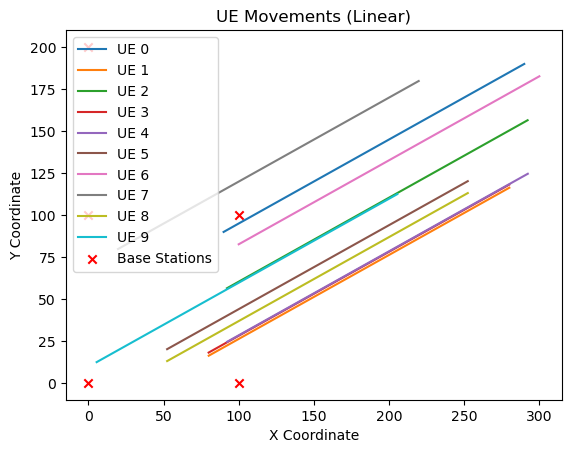

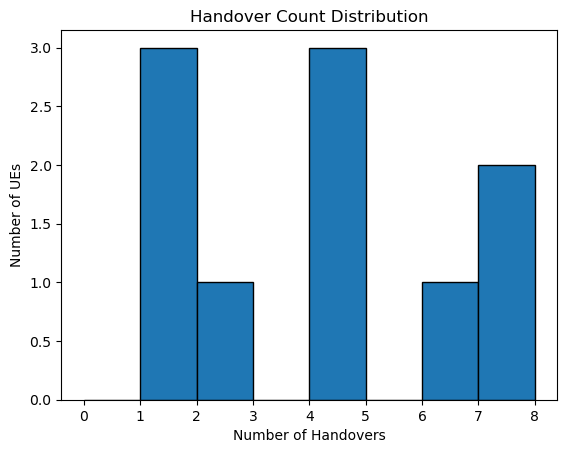

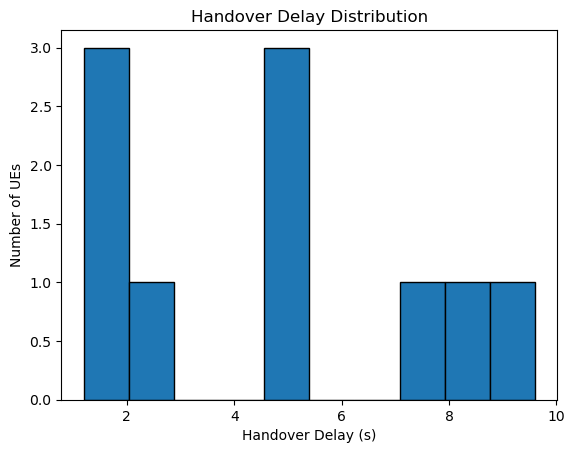

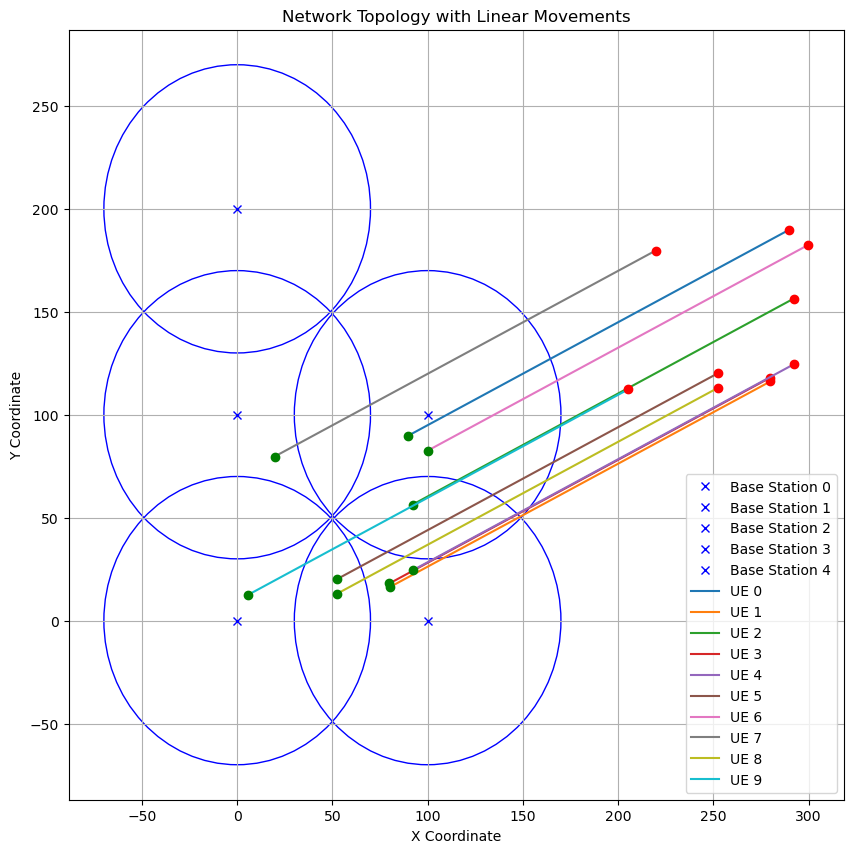

In [37]:
# Δίκτυο με γραμμική κίνηση χρησιμοποιώντας τον αλγόριθμο RSSI-based handover
# Δημιουργούμε ένα δίκτυο με 5 σταθμούς βάσης και 10 UEs, με σταθμούς βάσης σε διάταξη πλέγματος.
network_random = Network(num_stations=5, num_ues=10, grid=True) 
# Εκτελούμε προσομοίωση με 200 βήματα, χρησιμοποιώντας τον αλγόριθμο RSSI-based για τις εναλλαγές και γραμμικό μοτίβο κίνησης για τα UEs.
network_random.run_simulation(steps=200, handover_algorithm='rssi', mobility_pattern='linear')
# Αναλύουμε την απόδοση του δικτύου
network_random.analyze_performance()
# Δημιουργούμε γράφημα που δείχνει τις διαδρομές κίνησης όλων των UEs με τίτλο "UE Movements (Linear)"
network_random.plot_ue_movements('UE Movements (Linear)')
# Δημιουργούμε γράφημα που δείχνει την κατανομή των εναλλαγών (handover) μεταξύ των UEs.
network_random.plot_handover_distribution()
# Δημιουργούμε γράφημα που δείχνει την κατανομή των καθυστερήσεων (handover delays) μεταξύ των UEs.
network_random.plot_handover_delay_distribution()
# Δημιουργούμε γράφημα που δείχνει την τοπολογία του δικτύου, συμπεριλαμβανομένων των σταθμών βάσης και των κινήσεων UEs σε ευθύγραμμη κίνηση.
network_random.plot_network_topology(mobility_pattern='linear')

Total Handovers: 130, Avg Delay: 15.600000000000003


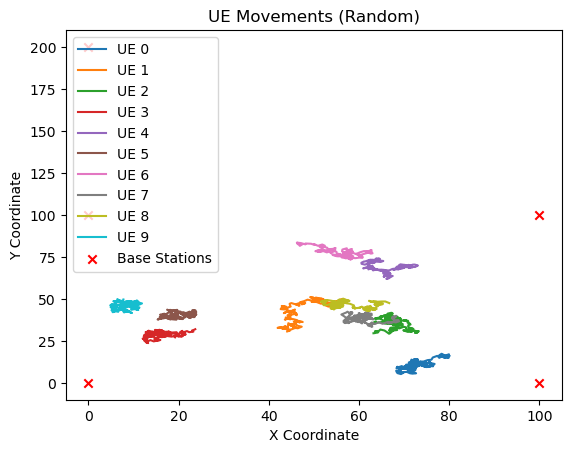

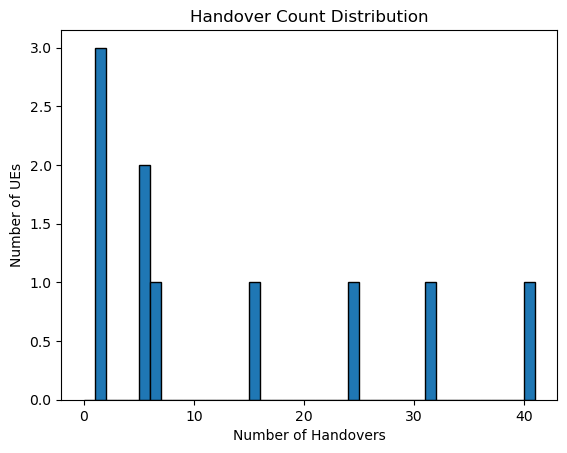

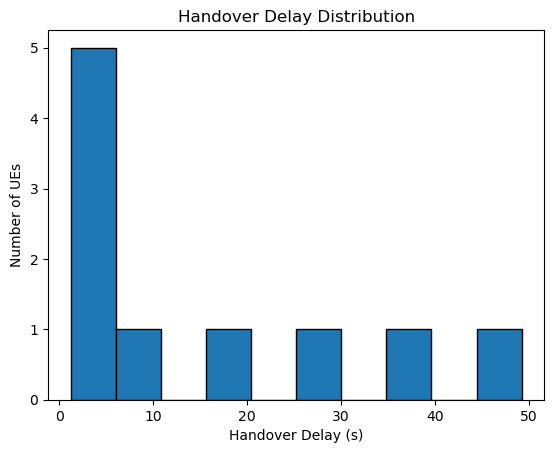

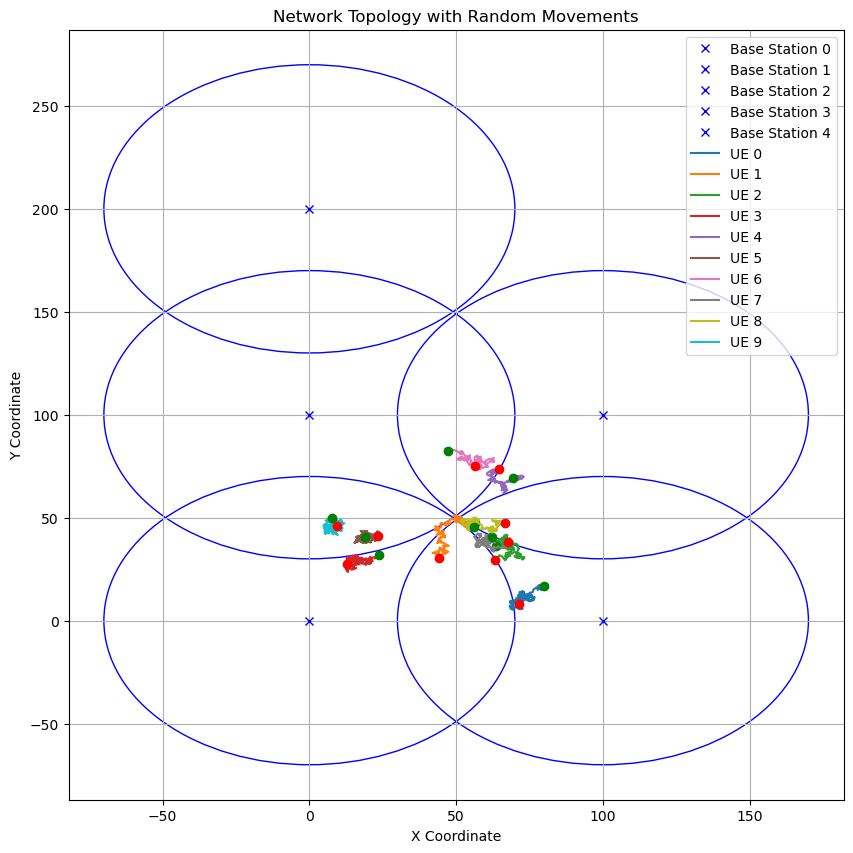

In [35]:
# Δίκτυο με τυχαία κίνηση χρησιμοποιώντας τον αλγόριθμο RSSI-based handover
network_random = Network(num_stations=5, num_ues=10, grid=True)
network_random.run_simulation(steps=200, handover_algorithm='rssi', mobility_pattern='random')
network_random.analyze_performance()
network_random.plot_ue_movements('UE Movements (Random)')
network_random.plot_handover_distribution()
network_random.plot_handover_delay_distribution()
network_random.plot_network_topology(mobility_pattern='random')

Total Handovers: 30, Avg Delay: 3.3604662215089767


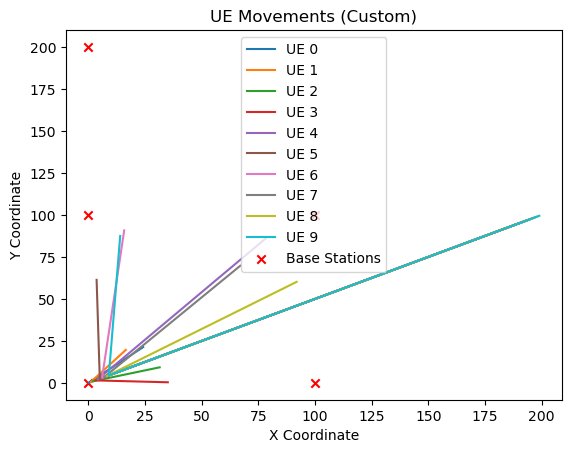

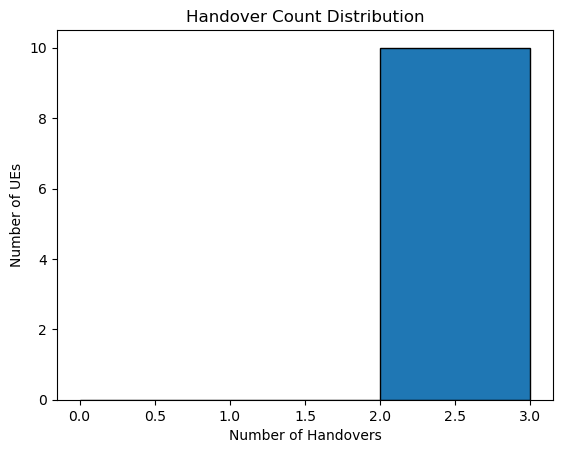

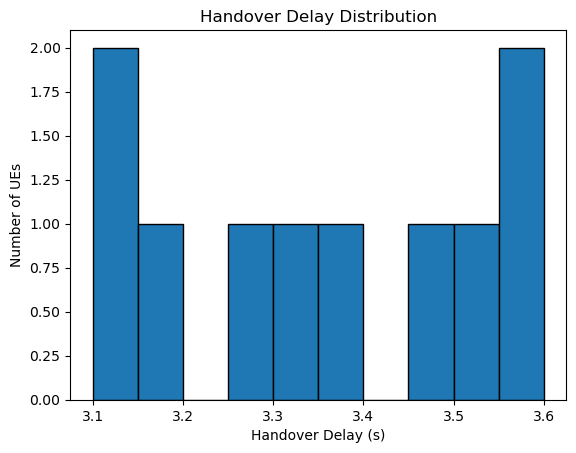

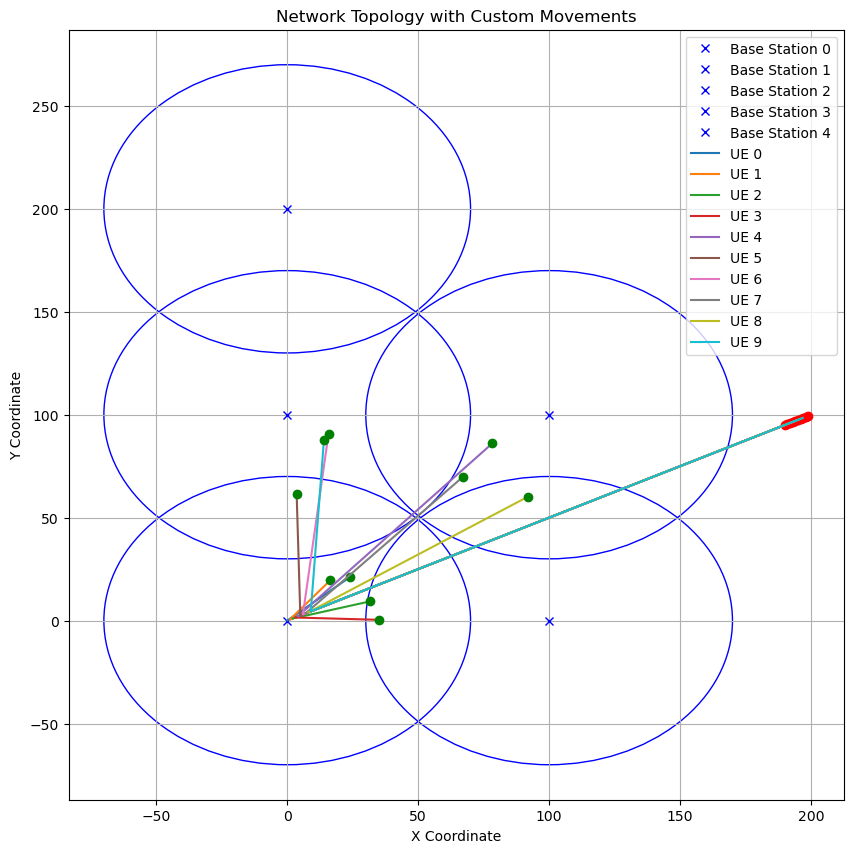

In [36]:
# Δίκτυο με προκαθορισμένη διαδρομή χρησιμοποιώντας τον αλγόριθμο RSSI-based handover
network_custom = Network(num_stations=5, num_ues=10, grid=True)
# Ορίζουμε μια προσαρμοσμένη διαδρομή (custom path) για τα UEs, όπου κάθε σημείο έχει συντεταγμένες (i, i * 0.5), με το i να μεταβάλλεται από 0 έως 199.
custom_path = [(i, i * 0.5) for i in range(200)]  
network_custom.run_simulation(steps=200, handover_algorithm='rssi', mobility_pattern='custom', custom_path=custom_path)
network_custom.analyze_performance()
network_custom.plot_ue_movements('UE Movements (Custom)')
network_custom.plot_handover_distribution()
network_custom.plot_handover_delay_distribution()
network_custom.plot_network_topology(mobility_pattern='custom')

# Threshold-based handover

Total Handovers: 49, Avg Delay: 5.843829982305115


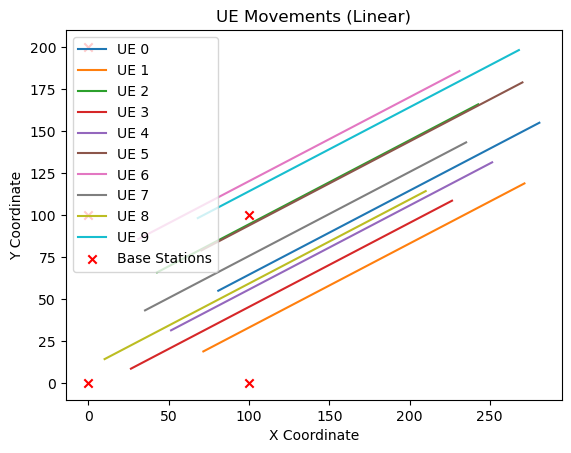

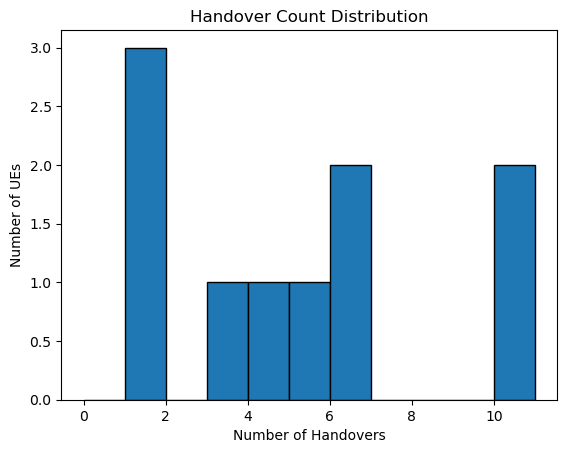

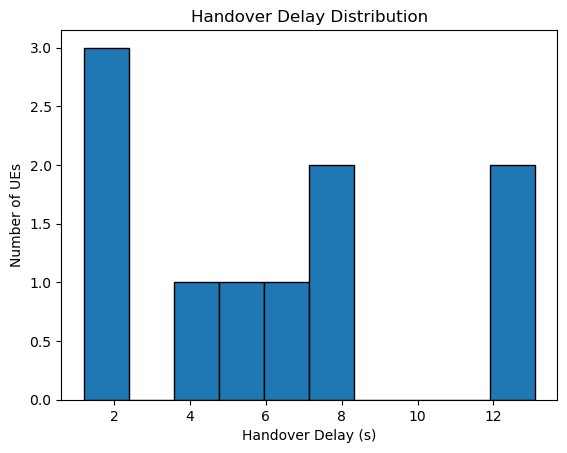

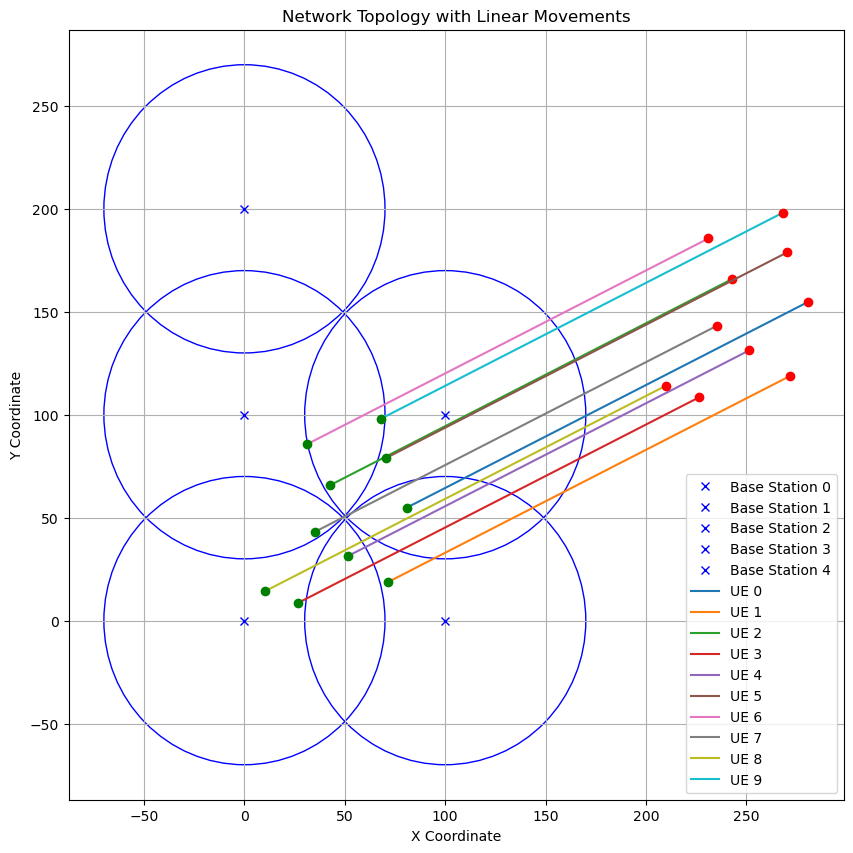

In [13]:
# Δίκτυο με γραμμική κίνηση χρησιμοποιώντας τον αλγόριθμο Τhreshold-based handover
network_linear = Network(num_stations=5, num_ues=10, grid=True)
network_linear.run_simulation(steps=200, handover_algorithm='threshold', mobility_pattern='linear')
network_linear.analyze_performance()
network_linear.plot_ue_movements('UE Movements (Linear)')
network_linear.plot_handover_distribution()
network_linear.plot_handover_delay_distribution()
network_linear.plot_network_topology(mobility_pattern='linear')

Total Handovers: 168, Avg Delay: 20.131829902270304


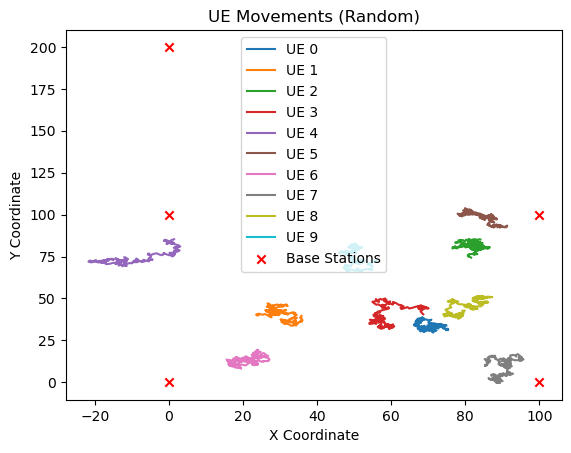

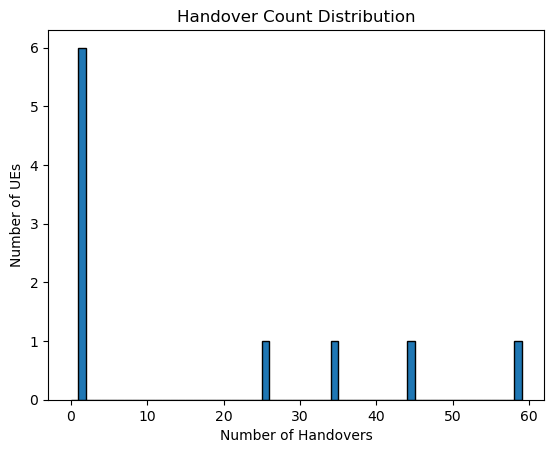

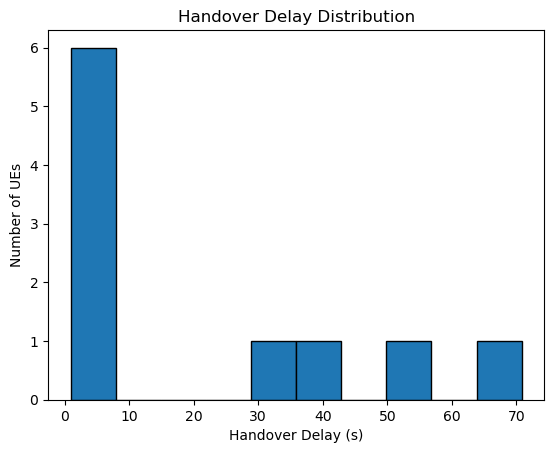

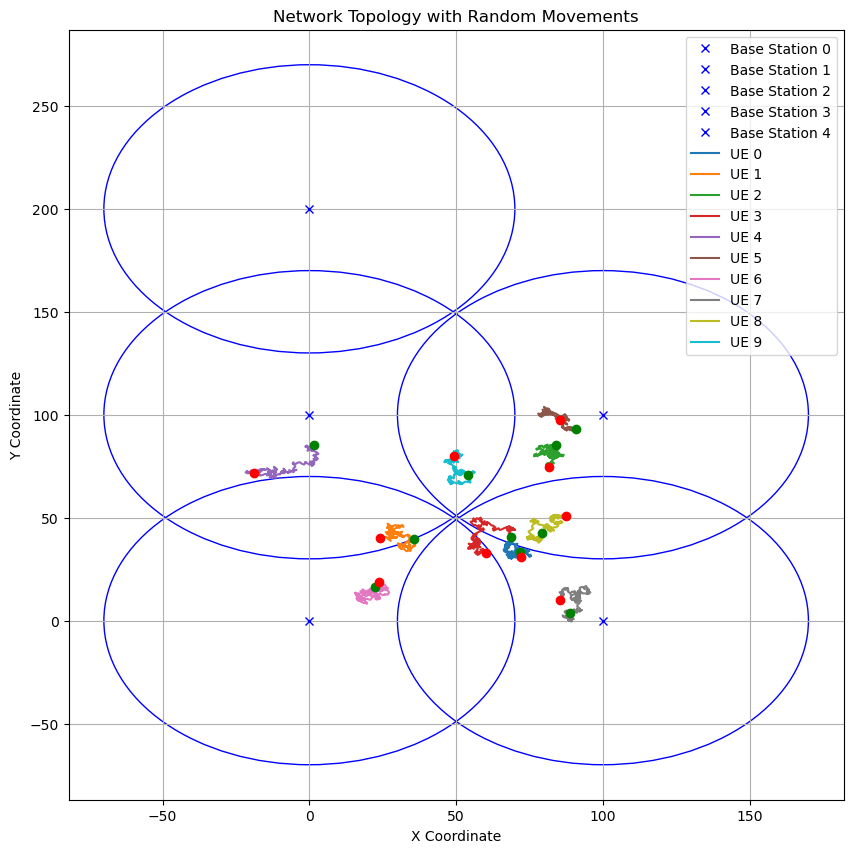

In [14]:
# Δίκτυο με τυχαία κίνηση χρησιμοποιώντας τον αλγόριθμο Τhreshold-based handover
network_random = Network(num_stations=5, num_ues=10, grid=True)
network_random.run_simulation(steps=200, handover_algorithm='threshold', mobility_pattern='random')
network_random.analyze_performance()
network_random.plot_ue_movements('UE Movements (Random)')
network_random.plot_handover_distribution()
network_random.plot_handover_delay_distribution()
network_random.plot_network_topology(mobility_pattern='random')

Total Handovers: 30, Avg Delay: 3.4187504540631664


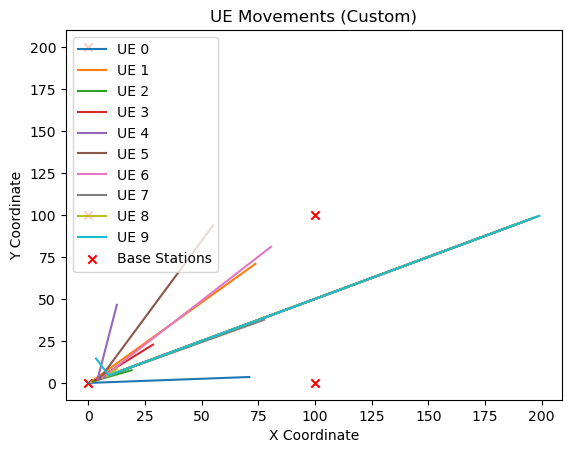

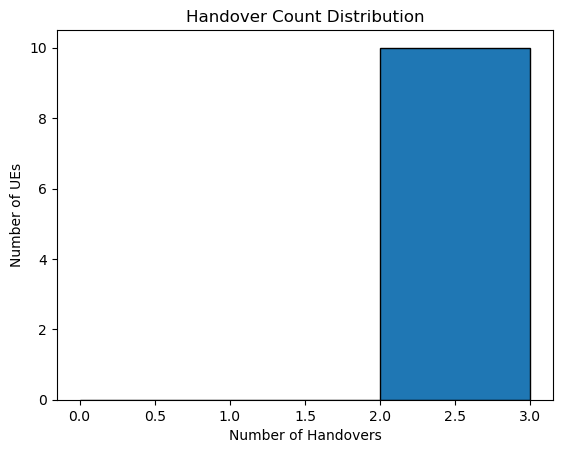

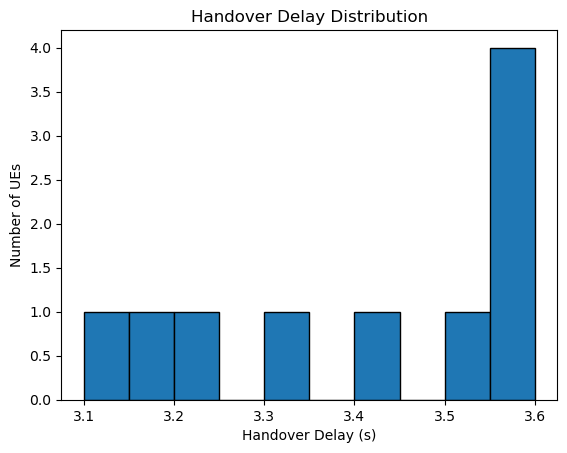

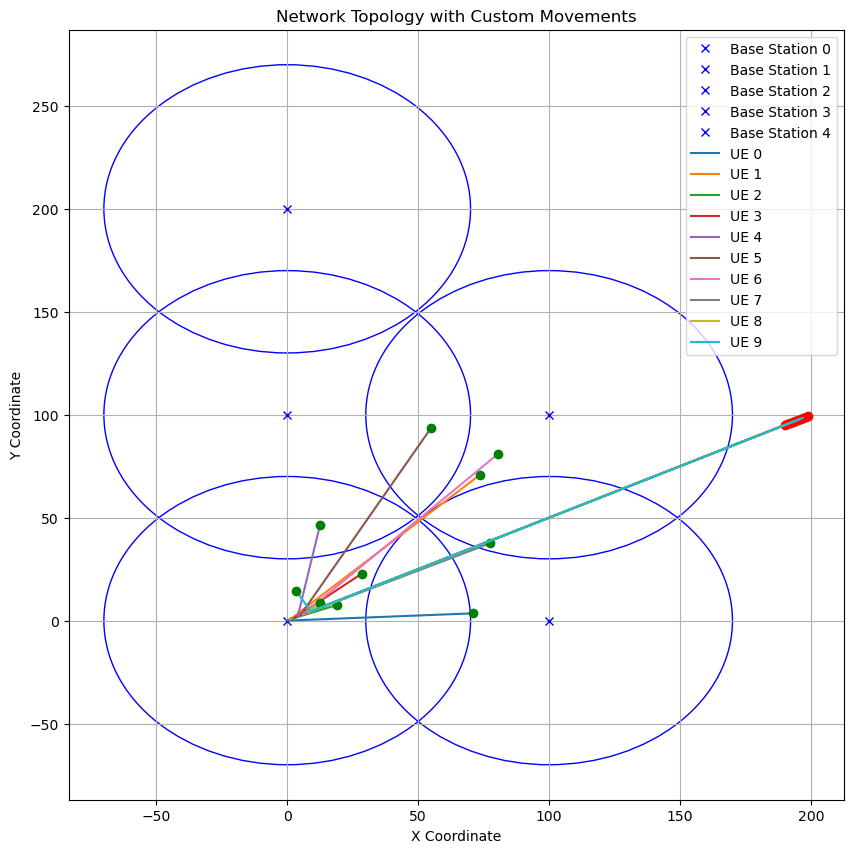

In [15]:
# Δίκτυο με προκαθορισμένη διαδρομή χρησιμοποιώντας τον αλγόριθμο Τhreshold-based handover
network_custom = Network(num_stations=5, num_ues=10, grid=True)
custom_path = [(i, i * 0.5) for i in range(200)]  
network_custom.run_simulation(steps=200, handover_algorithm='threshold', mobility_pattern='custom', custom_path=custom_path)
network_custom.analyze_performance()
network_custom.plot_ue_movements('UE Movements (Custom)')
network_custom.plot_handover_distribution()
network_custom.plot_handover_delay_distribution()
network_custom.plot_network_topology(mobility_pattern='custom')

# Cost-based handover

Total Handovers: 59, Avg Delay: 7.08


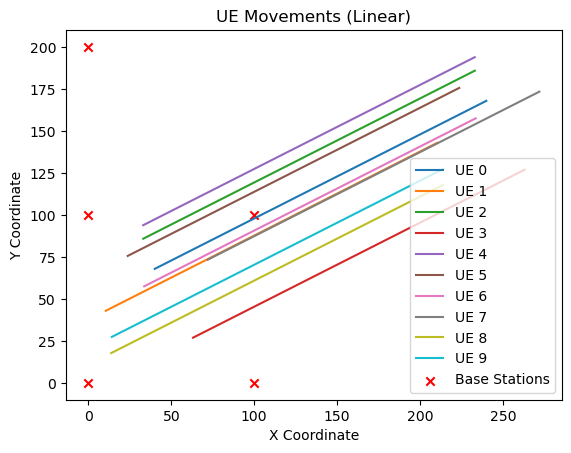

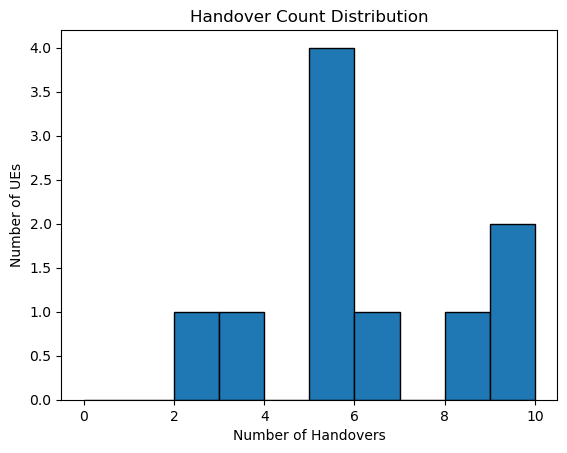

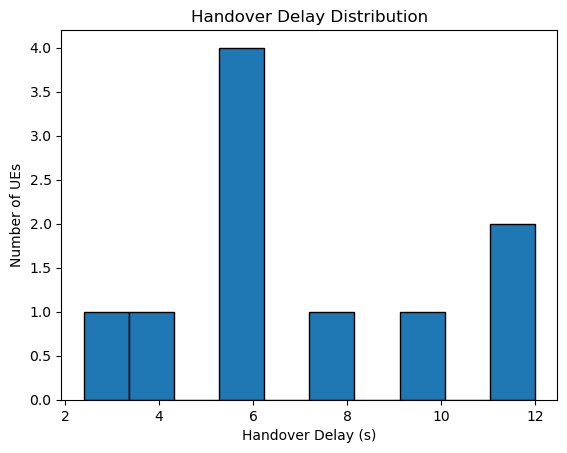

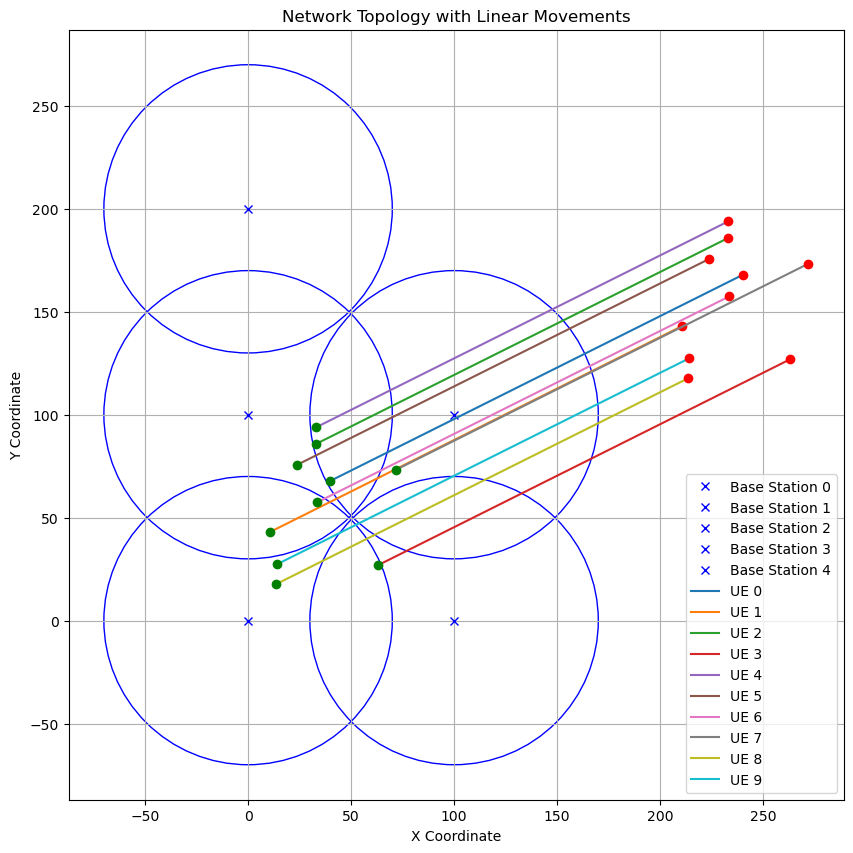

In [16]:
# Δίκτυο με γραμμική κίνηση χρησιμοποιώντας τον αλγόριθμο Cost-based handover
network_linear = Network(num_stations=5, num_ues=10, grid=True)
network_linear.run_simulation(steps=200, handover_algorithm='cost', mobility_pattern='linear')
network_linear.analyze_performance()
network_linear.plot_ue_movements('UE Movements (Linear)')
network_linear.plot_handover_distribution()
network_linear.plot_handover_delay_distribution()
network_linear.plot_network_topology(mobility_pattern='linear')

Total Handovers: 60, Avg Delay: 7.198778639719346


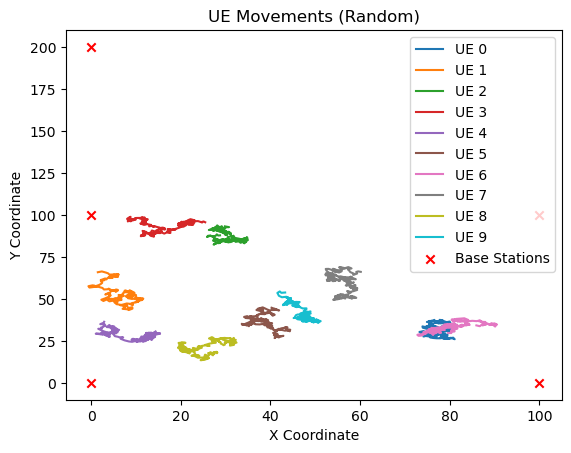

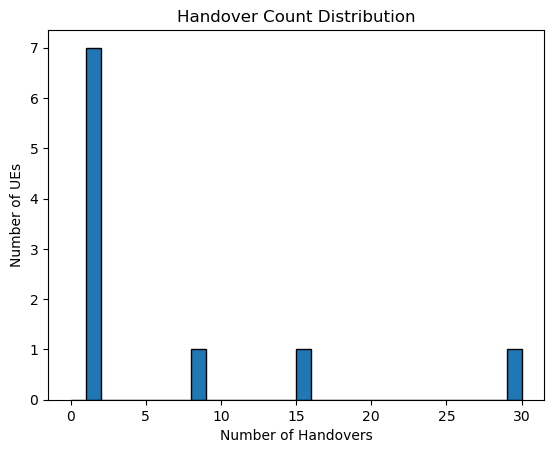

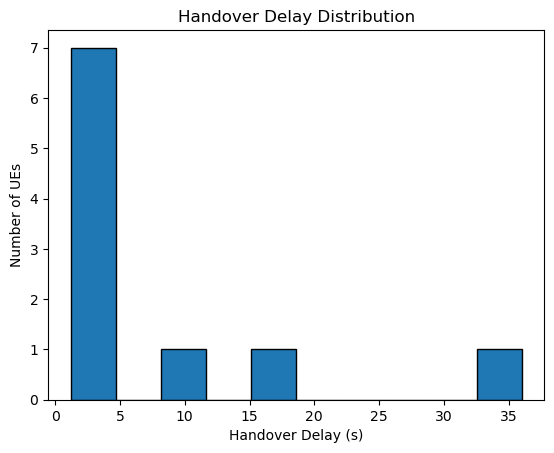

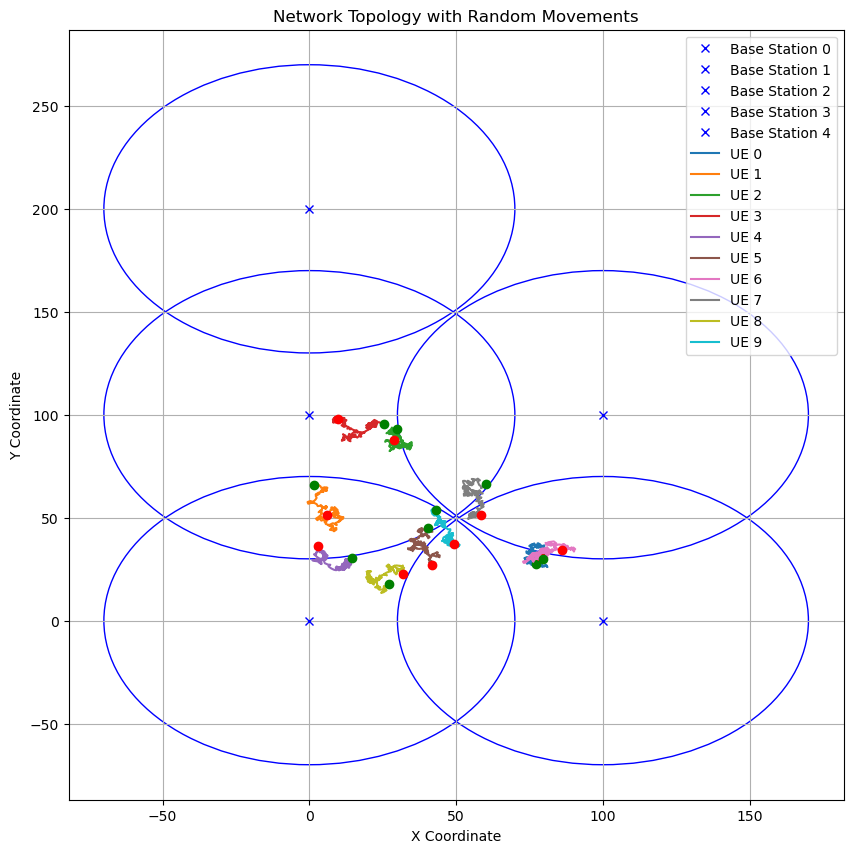

In [17]:
# Δίκτυο με τυχαία κίνηση χρησιμοποιώντας τον αλγόριθμο Cost-based handover
network_random = Network(num_stations=5, num_ues=10, grid=True)
network_random.run_simulation(steps=200, handover_algorithm='cost', mobility_pattern='random')
network_random.analyze_performance()
network_random.plot_ue_movements('UE Movements (Random)')
network_random.plot_handover_distribution()
network_random.plot_handover_delay_distribution()
network_random.plot_network_topology(mobility_pattern='random')

Total Handovers: 40, Avg Delay: 4.454715501683189


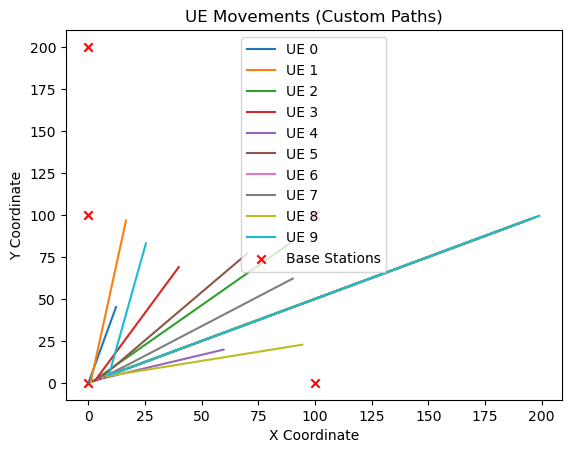

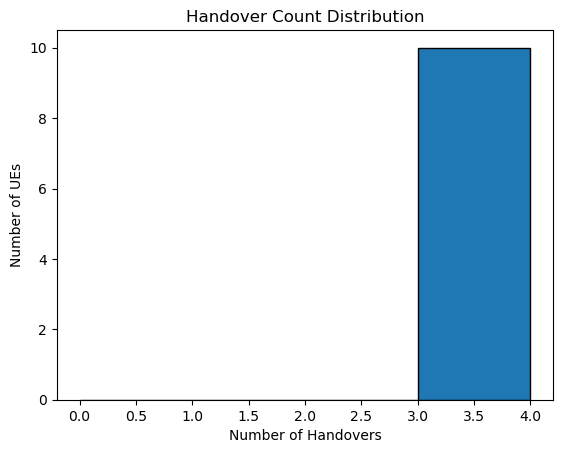

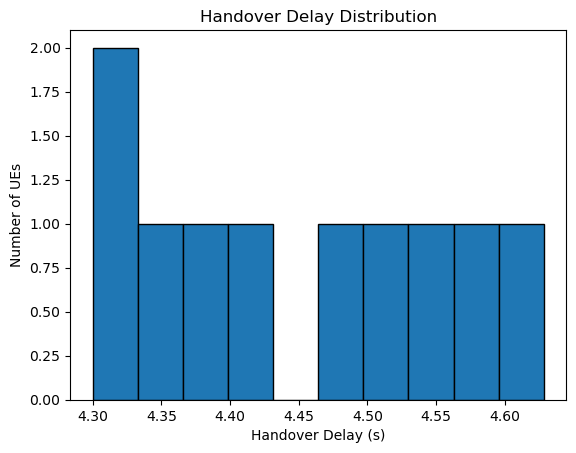

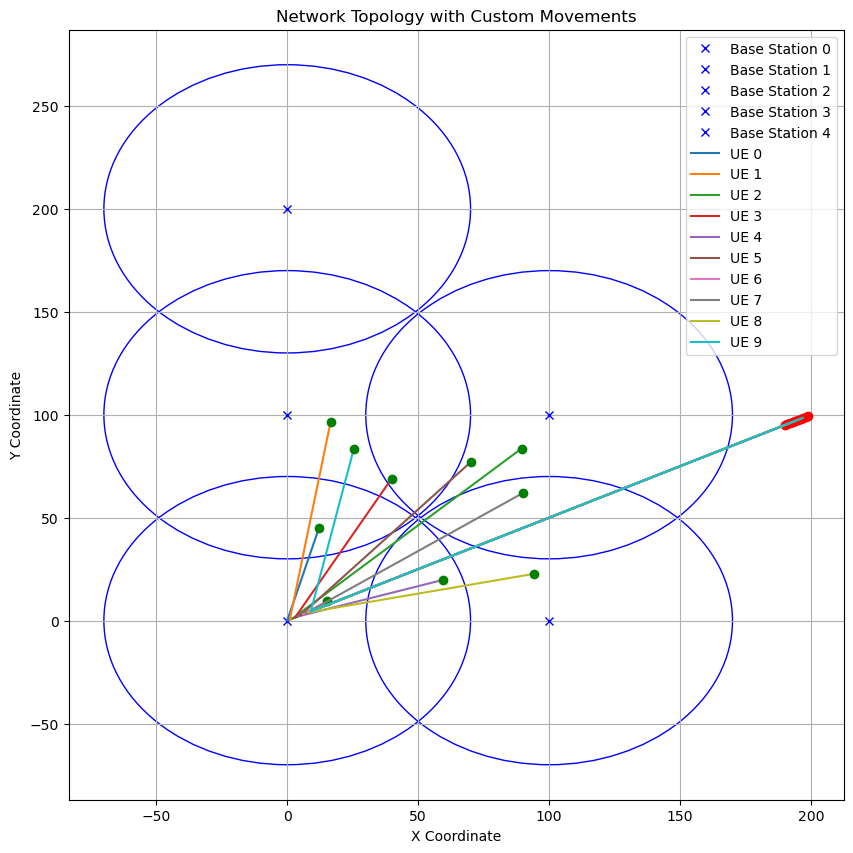

In [18]:
# Δίκτυο με προκαθορισμένη διαδρομή χρησιμοποιώντας τον αλγόριθμο Cost-based handover
network_custom = Network(num_stations=5, num_ues=10, grid=True)
custom_path = [(i, i * 0.5) for i in range(200)]  
network_custom.run_simulation(steps=200, handover_algorithm='cost', mobility_pattern='custom', custom_path=custom_path)
network_custom.analyze_performance()
network_custom.plot_ue_movements('UE Movements (Custom Paths)')
network_custom.plot_handover_distribution()
network_custom.plot_handover_delay_distribution()
network_custom.plot_network_topology(mobility_pattern='custom')